In [1]:
import pandas as pd

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [10]:
data=pd.read_csv("retail_sales_dataset.csv")
data.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,24-11-2023,CUST001,Male,34,Beauty,3,50,150
1,2,27-02-2023,CUST002,Female,26,Clothing,2,500,1000
2,3,13-01-2023,CUST003,Male,50,Electronics,1,30,30
3,4,21-05-2023,CUST004,Male,37,Clothing,1,500,500
4,5,06-05-2023,CUST005,Male,30,Beauty,2,50,100


In [4]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [5]:
data.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [6]:
data.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [7]:
data.drop_duplicates(inplace=True)

In [8]:
data.drop_duplicates().sum()

Transaction ID                                                 500500
Date                2023-11-242023-02-272023-01-132023-05-212023-0...
Customer ID         CUST001CUST002CUST003CUST004CUST005CUST006CUST...
Gender              MaleFemaleMaleMaleMaleFemaleMaleMaleMaleFemale...
Age                                                             41392
Product Category    BeautyClothingElectronicsClothingBeautyBeautyC...
Quantity                                                         2514
Price per Unit                                                 179890
Total Amount                                                   456000
dtype: object

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [12]:
data["Date"]=pd.to_datetime(data["Date"])

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [14]:
data["Total Amount"].sum()

np.int64(456000)

In [15]:
data["Total Amount"].mean()

np.float64(456.0)

In [16]:
data["Total Amount"].median()

135.0

In [17]:
data["Total Amount"].mode()

0    50
Name: Total Amount, dtype: int64

In [18]:
data["Total Amount"].std()

559.997631555123

In [19]:
data["Month"]=data["Date"].dt.month
data["Year"]=data["Date"].dt.year

In [20]:
monthly_sales=data.groupby("Month")["Total Amount"].sum()

In [21]:
print(monthly_sales)

Month
1     36980
2     44060
3     28990
4     33870
5     53150
6     36715
7     35465
8     36960
9     23620
10    46580
11    34920
12    44690
Name: Total Amount, dtype: int64


In [21]:
Gender_sales=data.groupby("Gender")["Total Amount"].sum()
print(Gender_sales)

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64


In [11]:
Category_sales=data.groupby("Product Category")["Total Amount"].sum()
print(Category_sales)

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64


In [ ]:
Category_gender = data.groupby(['Product Category', 'Gender'])['Total Amount'].sum().unstack()
print(Category_gender)

Gender            Female   Male
Product Category               
Beauty             74830  68685
Clothing           81275  74305
Electronics        76735  80170


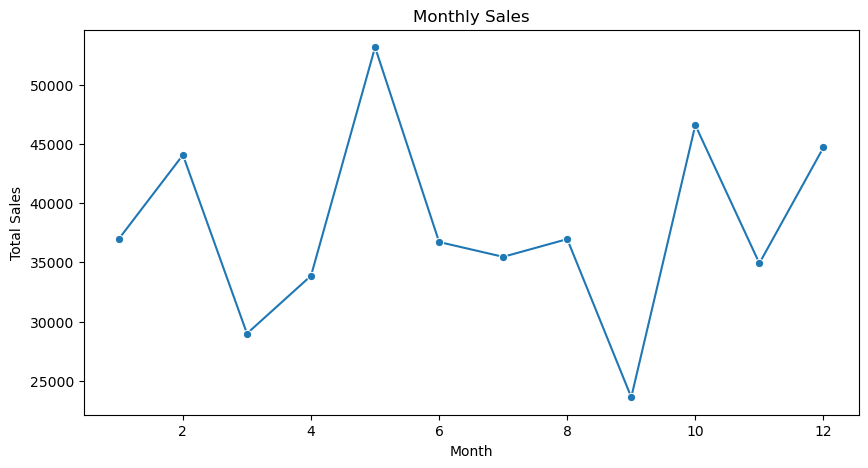

In [32]:
plt.figure(figsize=(10,5))
sns.lineplot(x=monthly_sales.index,y=monthly_sales.values,marker='o')
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

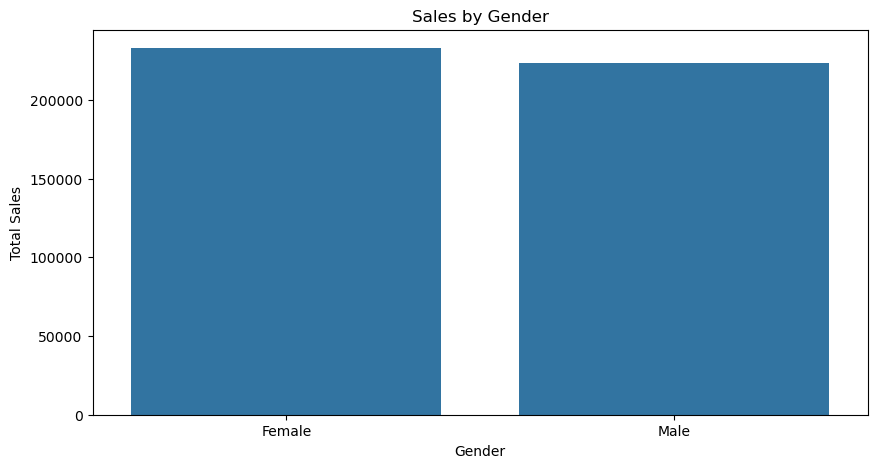

In [36]:
plt.figure(figsize=(10,5))
sns.barplot(x=Gender_sales.index,y=Gender_sales.values)
plt.title("Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales")
plt.show()

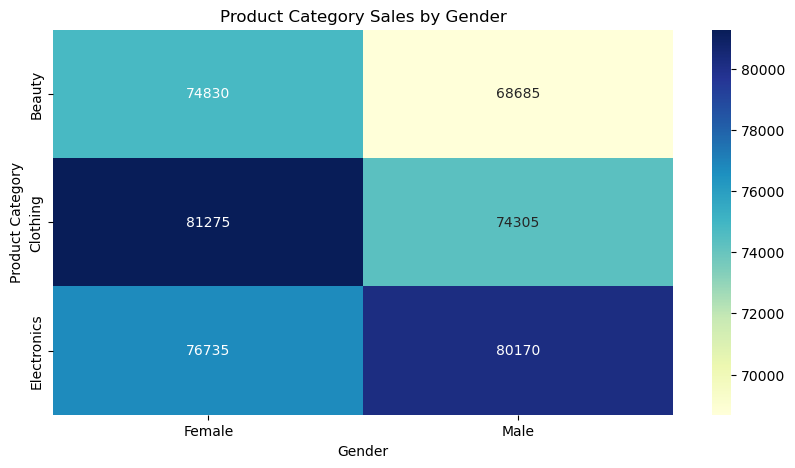

In [42]:
plt.figure(figsize=(10,5))
sns.heatmap(
    Category_gender,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu'
)

plt.title("Product Category Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Product Category")
plt.show()


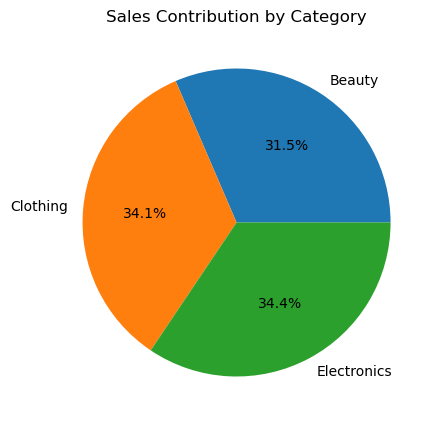

In [ ]:
plt.figure(figsize=(10,5))
plt.pie(Category_sales.values,labels=Category_sales.indexa,autopct='%1.1f%%')
plt.title("Sales Contribution by Category")
plt.show()

In [5]:
print("Business Recommendations:")
print("1. Introduce promotional campaigns between August and October to boost sales.")
print("2. Increase the variety of men's Beauty and Clothing products.")
print("3. Focus marketing efforts on top-performing product categories.")
print("4. Implement customer loyalty programs to encourage repeat purchases.")

Business Recommendations:
1. Introduce promotional campaigns between August and October to boost sales.
2. Increase the variety of men's Beauty and Clothing products.
3. Focus marketing efforts on top-performing product categories.
4. Implement customer loyalty programs to encourage repeat purchases.
